![Logo del Instituto](https://raw.githubusercontent.com/Alelop-Itu/machine12026nocturno/refs/heads/main/img/logoitqv1.jpg)

# EXTRACCIÓN DE CARACTERISTICAS PARA LA DETECCIÓN DE TUMORES CEREBRALES MEDIANTE ANALISIS EXPLORATORIO DE DATOS Y LA METODOLOGIA CRISP-DM 

![Logo de Python](https://raw.githubusercontent.com/Alelop-Itu/machine12026nocturno/refs/heads/main/img/python_logo.png)

* Integrantes: Cynthia Cuñez, Alejandra López, Judith Piedra, Emily Salvador y Cristhian Zumárraga
* Fecha: **22-07-2026**
* Repositorio: [Link del repositorio de Github](https://github.com/Alelop-Itu/TUMORES-CEREBRALES.git)

## PASO 1: Comprensión del negocio. 

**Dataset de Resonancia Magnética (MRI) para la Clasificación de Tumores Cerebrales**

**Descripción General**

Este conjunto de datos ha sido diseñado para impulsar la investigación en el análisis de imágenes médicas y el desarrollo de modelos de **Deep Learning** orientados a la clasificación multiclase de tumores cerebrales. Dado que el cráneo es una estructura rígida, cualquier crecimiento celular anormal (tumor) puede aumentar la presión intracraneal y causar daños neurológicos severos; por ello, la detección temprana y precisa es vital para el pronóstico del paciente.

**Composición del Dataset**

El dataset contiene un total de 7,200 imágenes de resonancia magnética humana, organizadas en cuatro categorías principales:

- Glioma
- Meningioma
- Tumor pituitario
- Sin tumor (No tumor)


**Distribución de los Datos**

Para garantizar una evaluación justa y evitar el sesgo en los modelos, el dataset presenta una distribución balanceada y está dividido de la siguiente manera:

|Conjunto|Imágenes por Clase|Total por Conjunto|
| --- | --- | --- |
|Entrenamiento (Training)|1,400|5,600|
|Pruebas (Testing)|400|1,600|
|Total Global|-|7,200|

**Origen y Calidad de los Datos**

Este conjunto es una versión curada que combina tres fuentes públicas de datos:
1. figshare brain MRI dataset
2. SARTAJ dataset (cuya clase "glioma" fue reemplazada por 3. imágenes verificadas de figshare debido a inconsistencias previas).
3. Br35H dataset (utilizado específicamente para la categoría "sin tumor").

**Mejoras en la Versión 2:** 

Se eliminaron imágenes duplicadas y se aseguró que no existiera solapamiento entre los conjuntos de entrenamiento y prueba para prevenir la fuga de datos (data leakage).

**Recomendaciones de Preprocesamiento**

Debido a que las imágenes presentan tamaños variables, es altamente recomendable aplicar las siguientes técnicas antes del entrenamiento de modelos:
- Redimensionamiento (Resizing) a un tamaño uniforme.
- Normalización de los valores de los píxeles.
- Eliminación de márgenes innecesarios en las capturas de MRI.

## PASO 2: Comprensión de los datos. 

Librerías necesarias para la gestión del entorno y comunicación con Kaggle.
* kaggle: Librería utilizada para la descarga programática y gestión de conjuntos de datos desde kaggle
* Módulo estándar de python utilizado para interactuar con el sistema operativo y gestionar las rutas de archivos del proyecto.


In [1]:
import kagglehub
import os

**Descarga de los datos**

Se realiza la conexión directa con el repositorio en la nube mediante el enlace de kaggle (https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset ) , asegurando la replicabilidad del proceso de obtención de datos mediante código python conforme a la metodología CRISP-DM.

In [2]:
# Descargar el dataset mediante código

path_original = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("El dataset ha sido descargado en:", path_original)

El dataset ha sido descargado en: C:\Users\JUDY\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


**Gestión de la Copia Local Aislada**

Con el fin de preservar la integridad de los datos originales y garantizar un entorno de desarrollo seguro, se ha implementado un mecanismo de aislamiento de datos mediante una copia local. Esta práctica protege el dataset original contra cualquier modificación accidental durante las fases de preprocesamiento, segmentación y experimentación.

**Estrategia de Aislamiento**
Se establece una distinción clara entre el directorio de descarga (fuente) y el directorio de trabajo (procesamiento). La copia local se gestiona bajo los siguientes criterios:

- Integridad del dataset original: El directorio de descarga actúa exclusivamente como una fuente de "solo lectura". Ninguna operación de transformación o limpieza altera los archivos originales descargados desde Kaggle.

- Entorno de trabajo segregado: Se crea una estructura de archivos duplicada en un directorio de trabajo específico (/data/processed/), donde se aplican las técnicas de procesamiento digital de imágenes (filtrado, umbralización, transformación de espacios de color).

- Consistencia del entorno: La copia se ejecuta mediante scripts de automatización de archivos que aseguran que, ante cualquier fallo en el pipeline de transformación, el equipo pueda "resetear" el entorno de trabajo volviendo a copiar los archivos desde la fuente original sin necesidad de re-descargar desde la nube.

**Implementación del Pipeline de Respaldo**
El proceso de replicación local sigue estos pasos técnicos:

1. Verificación de origen: El sistema confirma la presencia de los datos íntegros en el directorio de origen.

2. Sincronización de copia: Se ejecuta una función de replicación que clona la estructura de directorios y los archivos de imagen a un volumen local, aislado del historial de Git para evitar conflictos de peso en el repositorio.

3. Seguridad y Rollback: En caso de errores en la etapa de preprocesamiento, se habilita un comando de limpieza y re-copia, permitiendo la restauración inmediata del estado inicial de los datos de trabajo.

**Nota Metodológica:** Esta segregación es crítica en la metodología CRISP-DM durante la etapa de Preparación de Datos, ya que permite experimentar con diferentes técnicas de segmentación sin comprometer la base de datos maestra necesaria para el entrenamiento final del modelo.

In [3]:
# Crear la copia local aislada

import shutil

path = "./data_proyecto" # Ruta de trabajo de aquí en adelante

if not os.path.exists(path):
    shutil.copytree(path_original, path)
    print(f"Copia del dataset generada exitosamente en: {path}")
else:
    print("La carpeta de trabajo ya existe, no se va a generar la copia.")

La carpeta de trabajo ya existe, no se va a generar la copia.


**Inspección del dataset descargado**

Se utiliza *os.walk* para recorrer el sistema de archivos para identificar la jerarquía de directorios y confirmar la distribución de los archivos de imagen.

**Nota**: Es un paso fundamental para validar la integridad de la estructura antes del análisis exploratorio.

In [4]:
# Listar las carpetas principales para verificar la estructura

print("\nEstructura de carpetas:")

for root, dirs, files in os.walk(path):
    print(f"Carpeta: {root}, Archivos: {len(files)}")


Estructura de carpetas:
Carpeta: ./data_proyecto, Archivos: 1
Carpeta: ./data_proyecto\Testing, Archivos: 0
Carpeta: ./data_proyecto\Testing\glioma, Archivos: 400
Carpeta: ./data_proyecto\Testing\meningioma, Archivos: 400
Carpeta: ./data_proyecto\Testing\notumor, Archivos: 400
Carpeta: ./data_proyecto\Testing\pituitary, Archivos: 400
Carpeta: ./data_proyecto\Training, Archivos: 0
Carpeta: ./data_proyecto\Training\glioma, Archivos: 1400
Carpeta: ./data_proyecto\Training\meningioma, Archivos: 1400
Carpeta: ./data_proyecto\Training\notumor, Archivos: 1400
Carpeta: ./data_proyecto\Training\pituitary, Archivos: 1400


**Exploración de los datos**

Descarga de librerías para procesamiento digital de las imágenes y análisis de datos
* pandas: Biblioteca usada para la manipulación y estructuración de datos en formato tabular, necesaria para organizar la información en un dataset.
* cv2(OpenCV): Herramienta para la carga y el procesamiento avanzado de imágenes, utilizada para extraer propiedades técnicas como la resolución de las resonancias magnéticas.
* os: Módulo utilizado para garantizar la compatibilidad de rutas de archivos en el sistema operativo, permitiendo una navegación robusta a través de los directorios del dataset.


In [5]:
import pandas as pd
import cv2
import os

* Función *explorar_dataset_profundo*: Recorreo de forma recursiva la jerarquía del dataset, accediendo a los conjuntos de **Training** y **Testing**.
* Extracción de medatados: De cada imagen encontrada, se captura la categoría diagnóstica, resolución (ancho*alto) y guarda la información en el dataframe de pandas para facilitar análisis posteriores.
  
  -Número total de imágenes
  
  -Número de personas
  
  -Distribución de imágenes por persona
  
  -Resolución de las imágenes
  
  -Etiquetas disponibles
  
  -Tamaño del conjunto de datos

In [6]:
# Definir la ruta del dataset (ajusta 'path' a la variable resultante del paso anterior)
data_dir = path
def explorar_dataset_profundo(base_path):
    datos = []
    # Recorremos el dataset principal (Training y Testing)
    for carpeta_nivel1 in os.listdir(base_path):
        ruta_nivel1 = os.path.join(base_path, carpeta_nivel1)
        
        if os.path.isdir(ruta_nivel1):
            # Recorremos las categorías dentro de cada carpeta
            for categoria in os.listdir(ruta_nivel1):
                ruta_categoria = os.path.join(ruta_nivel1, categoria)
                
                if os.path.isdir(ruta_categoria):
                    for img_name in os.listdir(ruta_categoria):
                        img_path = os.path.join(ruta_categoria, img_name)
                        img = cv2.imread(img_path)
                        if img is not None:
                            datos.append({
                                'set': carpeta_nivel1, # Training o Testing
                                'categoria': categoria, # glioma, meningioma, etc.
                                'res_ancho': img.shape[1], #ancho
                                'res_alto': img.shape[0] #alto
                            })
    return pd.DataFrame(datos)

df_info = explorar_dataset_profundo(data_dir)

**Aclaraciones requeridas por el proyecto**

El dataset es anónimo: No se cuenta con datos de personas ni distribución por paciente para preservar la privacidad médica. Por tanto, no se cuenta con la información de los pacientes ni se puede extraer la distribución de imágenes por persona.

In [7]:
# Crear tabla de resumen con conteo y resoluciones
resumen = df_info.groupby(['set', 'categoria']).agg({
    'categoria': 'count',
    'res_ancho': 'mean',
    'res_alto': 'mean'
}).rename(columns={'categoria': 'cantidad', 'res_ancho': 'ancho_prom', 'res_alto': 'alto_prom'})

# Mostrar como tabla formateada
print("Resumen del Dataset:")
display(resumen)

#Total de imágenes encontradas
print(f"\nTotal de imágenes encontradas: {len(df_info)}")

# Etiquetas disponibles
print(f"Etiquetas (clases) detectadas: {list(df_info['categoria'].unique())}")

Resumen del Dataset:


cantidad  ancho_prom   alto_prom
set      categoria                                   
Testing  glioma           400  487.415000  492.127500
         meningioma       400  456.347500  461.600000
         notumor          400  289.617500  291.897500
         pituitary        400  506.880000  506.880000
Training glioma          1400  512.000000  512.000000
         meningioma      1400  495.413571  497.037857
         notumor         1400  313.550714  327.355000
         pituitary       1400  513.090714  512.658571


Total de imágenes encontradas: 7200
Etiquetas (clases) detectadas: ['glioma', 'meningioma', 'notumor', 'pituitary']


**Visualización de una muestra representativa de imágenes del dataset para comprender su variabilidad**

* matplotlib.pyplot: Se usa para gestionar la disposición y renderizado de las gráficas.
* Mediante un bucle for, el código filtra  el DataFrame para extraer una muestra representativa (la primera imagen) de cada categoría
* Se reconstruye la ruta física de cada archivo, se carga mediante OpenCV (cv2.imread) y se realiza una conversión de color (cv2.cvtColor) de formato BGR a RGB, debido a que OpenCV y Matplotlib utilizan estándares de color distintos.
* Visualización en subgráficos: Se organiza la salida en una única fila (plt.subplot), mostrando cada imagen con su respectiva etiqueta de categoría y eliminando los ejes (plt.axis('off')) para una mejorar la visualización.

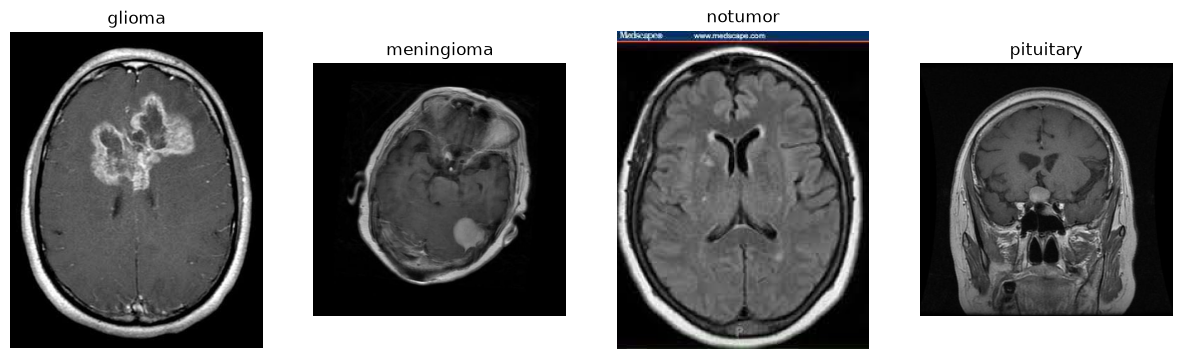

In [8]:
import matplotlib.pyplot as plt

# Visualizar una imagen por categoría
plt.figure(figsize=(15, 5))
categorias = df_info['categoria'].unique()

for i, cat in enumerate(categorias):
    
    # Buscar una imagen de esa categoría
    ruta_img = df_info[df_info['categoria'] == cat].iloc[0]
    
    # Reconstruir la ruta completa
    img = cv2.imread(os.path.join(path, ruta_img['set'], cat, os.listdir(os.path.join(path, ruta_img['set'], cat))[0]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(categorias), i+1)
    plt.imshow(img)
    plt.title(cat)
    plt.axis('off')
    
plt.show()

## PASO 3: Análisis Exploratorio de Datos (EDA)

El análisis exploratorio de datos es fundamental para entender la calidad, estructura y características del conjunto de datos antes de su utilización en modelos de Machine Learning. Durante esta fase se identificarán problemas potenciales que puedan afectar el desempeño de algoritmos posteriores.


### 3.1 Distribución de Imágenes por Clase

La distribución equilibrada de clases es fundamental para garantizar que los modelos de ML no presenten sesgo hacia categorías con mayor representación. Se analiza:
- Cantidad total de imágenes por categoría diagnóstica
- Proporción respecto al total de datos
- Comparación entre conjuntos de entrenamiento y prueba


In [9]:
# Análisis de distribución por clase
distribucion_clase = df_info['categoria'].value_counts().sort_values(ascending=False)
distribucion_por_set = df_info.groupby(['set', 'categoria']).size().unstack(fill_value=0)

print("=" * 60)
print("DISTRIBUCIÓN TOTAL DE IMÁGENES POR CATEGORÍA")
print("=" * 60)
print(distribucion_clase)
print(f"\n")

# Calcular porcentajes
print("PORCENTAJE DE REPRESENTACIÓN:")
print("-" * 60)
for categoria, cantidad in distribucion_clase.items():
    porcentaje = (cantidad / len(df_info)) * 100
    print(f"{categoria:20s}: {cantidad:5d} imágenes ({porcentaje:6.2f}%)")

print(f"\n{'TOTAL':20s}: {len(df_info):5d} imágenes (100.00%)")

# Distribución por conjunto (Training/Testing)
print(f"\n{'=' * 60}")
print("DISTRIBUCIÓN POR CONJUNTO (TRAINING/TESTING)")
print("=" * 60)
print(distribucion_por_set)


DISTRIBUCIÓN TOTAL DE IMÁGENES POR CATEGORÍA
categoria
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64


PORCENTAJE DE REPRESENTACIÓN:
------------------------------------------------------------
glioma              :  1800 imágenes ( 25.00%)
meningioma          :  1800 imágenes ( 25.00%)
notumor             :  1800 imágenes ( 25.00%)
pituitary           :  1800 imágenes ( 25.00%)

TOTAL               :  7200 imágenes (100.00%)

DISTRIBUCIÓN POR CONJUNTO (TRAINING/TESTING)
categoria  glioma  meningioma  notumor  pituitary
set                                              
Testing       400         400      400        400
Training     1400        1400     1400       1400


### 3.2 Análisis de Balance del Dataset

Se evalúa si el dataset presenta desbalance de clases, lo cual es común en aplicaciones médicas donde ciertas condiciones son más prevalentes que otras.


In [10]:
# Calcular métricas de balance
distribucion_clase_array = distribucion_clase.values
clase_mayoritaria = distribucion_clase.max()
clase_minoritaria = distribucion_clase.min()
ratio_desbalance = clase_mayoritaria / clase_minoritaria

print("=" * 60)
print("ANÁLISIS DE BALANCE DEL DATASET")
print("=" * 60)
print(f"Clase mayoritaria (más representada): {distribucion_clase.idxmax()} ({clase_mayoritaria} imágenes)")
print(f"Clase minoritaria (menos representada): {distribucion_clase.idxmin()} ({clase_minoritaria} imágenes)")
print(f"Ratio de desbalance: {ratio_desbalance:.2f}:1")

if ratio_desbalance < 1.5:
    balance_status = "✓ DATASET EQUILIBRADO"
elif ratio_desbalance < 3:
    balance_status = "⚠ DATASET MODERADAMENTE DESBALANCEADO"
else:
    balance_status = "✗ DATASET ALTAMENTE DESBALANCEADO"

print(f"Estado: {balance_status}")
print(f"\nNota: Un ratio < 1.5 indica un dataset bien balanceado.")
print(f"Un ratio entre 1.5-3 requiere técnicas de balanceo.")
print(f"Un ratio > 3 requiere intervención significativa.")


ANÁLISIS DE BALANCE DEL DATASET
Clase mayoritaria (más representada): glioma (1800 imágenes)
Clase minoritaria (menos representada): glioma (1800 imágenes)
Ratio de desbalance: 1.00:1
Estado: ✓ DATASET EQUILIBRADO

Nota: Un ratio < 1.5 indica un dataset bien balanceado.
Un ratio entre 1.5-3 requiere técnicas de balanceo.
Un ratio > 3 requiere intervención significativa.


### 3.3 Estadísticas Descriptivas de las Imágenes

Se analizan las propiedades técnicas de las imágenes como resolución (ancho x alto), aspecto y variabilidad dimensional. Estas características son importantes para el preprocesamiento posterior.


In [11]:
# Cálculo de estadísticas descriptivas
df_info['aspecto_ratio'] = df_info['res_ancho'] / df_info['res_alto']

print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS DE RESOLUCIÓN")
print("=" * 60)

# Resumen general
print(f"{'Métrica':<25} {'Min':>15} {'Max':>15} {'Media':>15} {'Std':>15}")
print("-" * 70)
print(f"{'Ancho (píxeles)':<25} {df_info['res_ancho'].min():>15.0f} {df_info['res_ancho'].max():>15.0f} {df_info['res_ancho'].mean():>15.2f} {df_info['res_ancho'].std():>15.2f}")
print(f"{'Alto (píxeles)':<25} {df_info['res_alto'].min():>15.0f} {df_info['res_alto'].max():>15.0f} {df_info['res_alto'].mean():>15.2f} {df_info['res_alto'].std():>15.2f}")
print(f"{'Aspecto Ratio':<25} {df_info['aspecto_ratio'].min():>15.3f} {df_info['aspecto_ratio'].max():>15.3f} {df_info['aspecto_ratio'].mean():>15.3f} {df_info['aspecto_ratio'].std():>15.3f}")

# Estadísticas por categoría
print(f"\n{'=' * 70}")
print("ESTADÍSTICAS POR CATEGORÍA")
print("=" * 70)

for categoria in df_info['categoria'].unique():
    df_cat = df_info[df_info['categoria'] == categoria]
    print(f"\n{categoria.upper()}")
    print("-" * 70)
    print(f"{'  Imágenes:':<20} {len(df_cat)}")
    print(f"{'  Ancho (media±std):':<20} {df_cat['res_ancho'].mean():.2f} ± {df_cat['res_ancho'].std():.2f}")
    print(f"{'  Alto (media±std):':<20} {df_cat['res_alto'].mean():.2f} ± {df_cat['res_alto'].std():.2f}")
    print(f"{'  Aspecto Ratio:':<20} {df_cat['aspecto_ratio'].mean():.3f} ± {df_cat['aspecto_ratio'].std():.3f}")


ESTADÍSTICAS DESCRIPTIVAS DE RESOLUCIÓN
Métrica                               Min             Max           Media             Std
----------------------------------------------------------------------
Ancho (píxeles)                       150            1375          453.30          130.05
Alto (píxeles)                        167            1446          456.90          124.40
Aspecto Ratio                       0.645           1.786           0.990           0.092

ESTADÍSTICAS POR CATEGORÍA

GLIOMA
----------------------------------------------------------------------
  Imágenes:          1800
  Ancho (media±std): 506.54 ± 36.92
  Alto (media±std):  507.58 ± 34.19
  Aspecto Ratio:     0.998 ± 0.030

MENINGIOMA
----------------------------------------------------------------------
  Imágenes:          1800
  Ancho (media±std): 486.73 ± 85.44
  Alto (media±std):  489.16 ± 80.54
  Aspecto Ratio:     0.993 ± 0.058

NOTUMOR
----------------------------------------------------------------

### 3.4 Histogramas de Intensidades de Píxeles

Las imágenes MRI contienen información valiosa codificada en la intensidad de los píxeles. El análisis de histogramas permite identificar:
- Rango dinámico de intensidades
- Presencia de outliers o anomalías
- Diferencias entre categorías diagnósticas
- Calidad de la imagen (contraste y brillo)


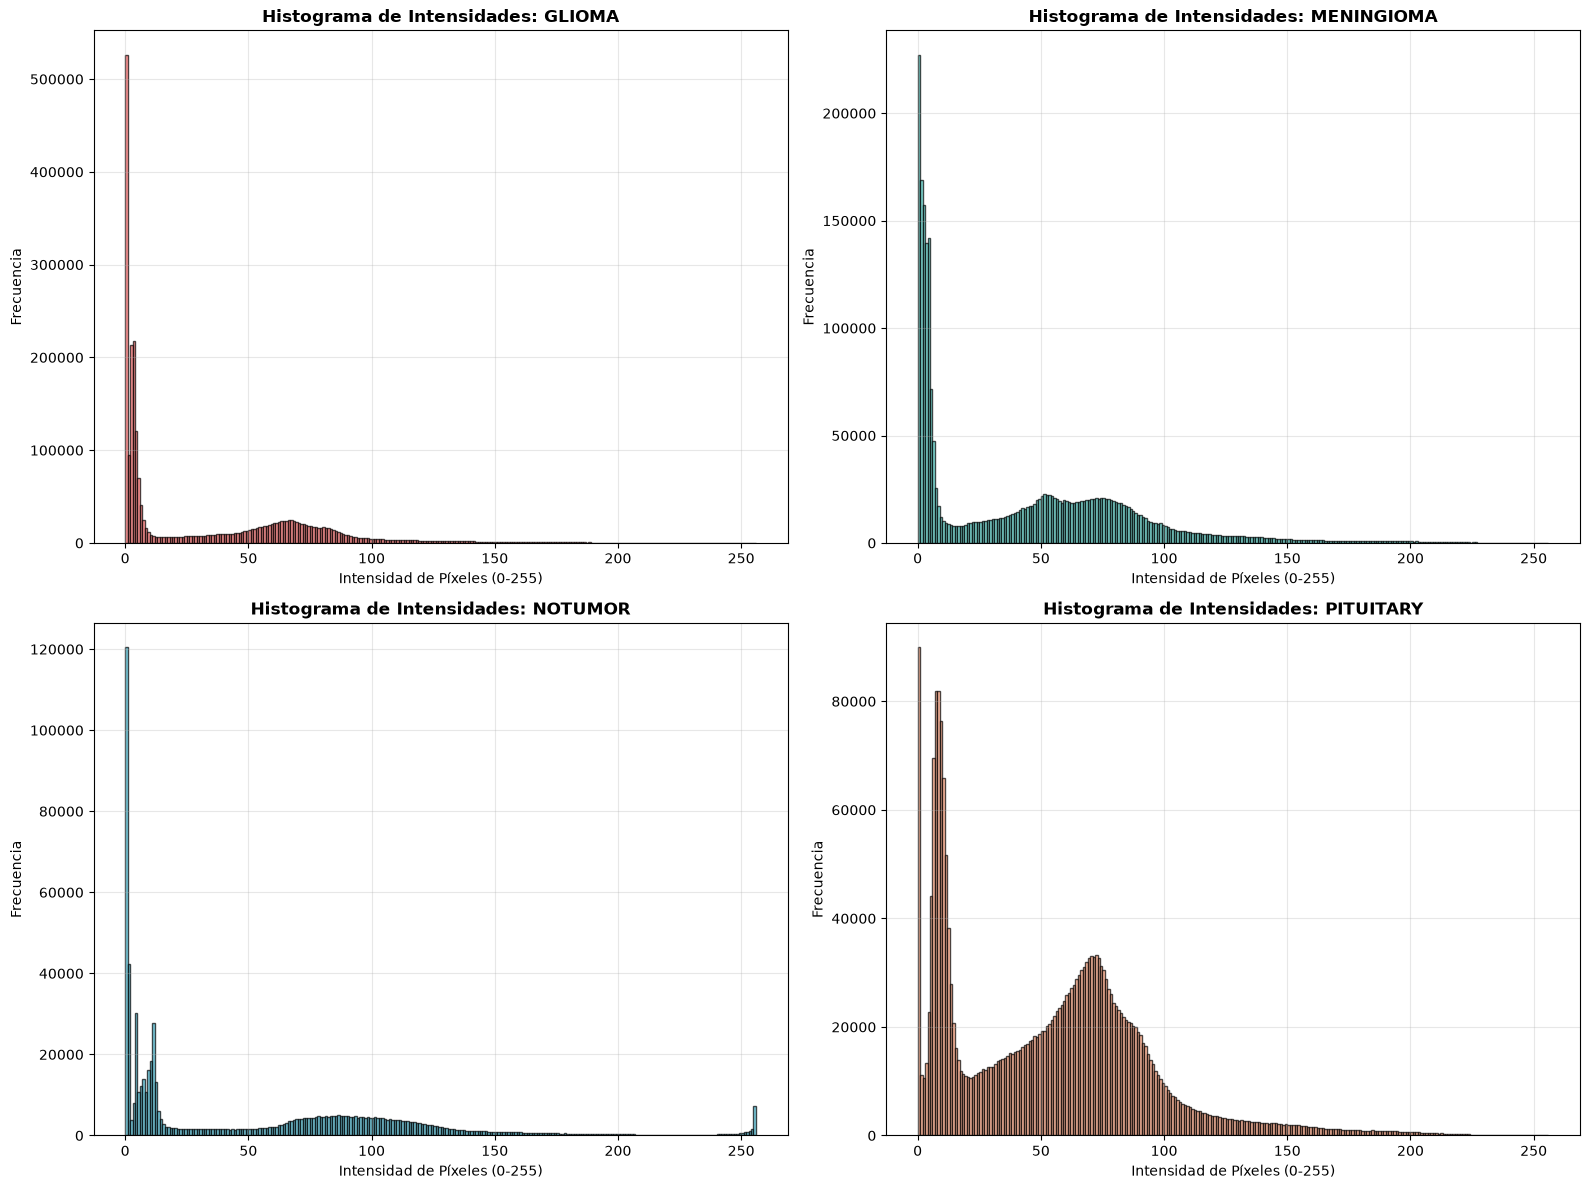

In [12]:
# Histogramas de intensidades de píxeles por categoría
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

categorias_list = df_info['categoria'].unique()
colores_dist = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, (ax, categoria) in enumerate(zip(axes.flat, categorias_list)):
    # Recolectar todas las intensidades de píxeles de una categoría
    todas_intensidades = []
    
    img_dir = os.path.join(data_dir, 'Training', categoria)
    
    # Recolectar píxeles de varias imágenes de la categoría
    for img_name in os.listdir(img_dir)[:10]:  # Primeras 10 imágenes
        img_path = os.path.join(img_dir, img_name)
        if img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                todas_intensidades.extend(img.flatten().tolist())
    
    # Crear histograma
    if todas_intensidades:
        ax.hist(todas_intensidades, bins=256, range=(0, 256), 
               color=colores_dist[idx], alpha=0.7, edgecolor='black')
        ax.set_title(f'Histograma de Intensidades: {categoria.upper()}', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Intensidad de Píxeles (0-255)')
        ax.set_ylabel('Frecuencia')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 3.5 Análisis de Brillo y Contraste

El brillo y contraste son propiedades críticas en imágenes médicas. Imágenes con brillo y contraste inapropiados pueden afectar significativamente la capacidad de identificar anomalías. Se calcula:
- **Brillo**: promedio de intensidades (0-255)
- **Contraste**: desviación estándar de intensidades
- Rango dinámico: (máximo - mínimo)


In [13]:
# Calcular brillo, contraste y rango dinámico
# muestra a 10 imágenes por categoría para análisis representativo
import numpy as np
df_muestra = df_info.groupby(['set', 'categoria']).head(10).reset_index(drop=True)

# Extraer intensidades de la muestra ampliada
df_intensidades_list = []
for idx, row in df_muestra.iterrows():
    img_dir = os.path.join(data_dir, row['set'], row['categoria'])
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    if img_files:
        img_path = os.path.join(img_dir, img_files[0])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            df_intensidades_list.append({
                'categoria': row['categoria'],
                'set': row['set'],
                'min_intensidad': img.min(),
                'max_intensidad': img.max(),
                'mean_intensidad': img.mean(),
                'std_intensidad': img.std(),
                'median_intensidad': np.median(img)
            })

df_intensidades = pd.DataFrame(df_intensidades_list)

df_intensidades['brillo'] = df_intensidades['mean_intensidad']  # Brillo = media de intensidad
df_intensidades['contraste'] = df_intensidades['std_intensidad']  # Contraste = desv. est.
df_intensidades['rango_dinamico'] = df_intensidades['max_intensidad'] - df_intensidades['min_intensidad']

print("=" * 80)
print("ANÁLISIS DE BRILLO Y CONTRASTE")
print("=" * 80)

for categoria in df_intensidades['categoria'].unique():
    df_cat = df_intensidades[df_intensidades['categoria'] == categoria]
    
    print(f"\n{categoria.upper()}")
    print("-" * 80)
    print(f"{'Métrica':<25} {'Min':>15} {'Max':>15} {'Media':>15} {'Std':>15}")
    print("-" * 80)
    print(f"{'Brillo (media int.)':<25} {df_cat['brillo'].min():>15.2f} {df_cat['brillo'].max():>15.2f} {df_cat['brillo'].mean():>15.2f} {df_cat['brillo'].std():>15.2f}")
    print(f"{'Contraste (std int.)':<25} {df_cat['contraste'].min():>15.2f} {df_cat['contraste'].max():>15.2f} {df_cat['contraste'].mean():>15.2f} {df_cat['contraste'].std():>15.2f}")
    print(f"{'Rango Dinámico':<25} {df_cat['rango_dinamico'].min():>15.2f} {df_cat['rango_dinamico'].max():>15.2f} {df_cat['rango_dinamico'].mean():>15.2f} {df_cat['rango_dinamico'].std():>15.2f}")

# Clasificación de brillo
print(f"\n{'=' * 80}")
print("CLASIFICACIÓN DE IMÁGENES POR BRILLO")
print("=" * 80)
df_intensidades['clasificacion_brillo'] = pd.cut(df_intensidades['brillo'], 
                                                  bins=[0, 80, 130, 160, 255],
                                                  labels=['Oscuro', 'Medio-Oscuro', 'Medio-Brillante', 'Brillante'])

print(df_intensidades['clasificacion_brillo'].value_counts().sort_index())


ANÁLISIS DE BRILLO Y CONTRASTE

GLIOMA
--------------------------------------------------------------------------------
Métrica                               Min             Max           Media             Std
--------------------------------------------------------------------------------
Brillo (media int.)                 34.54           66.03           50.29           16.15
Contraste (std int.)                36.68           60.05           48.37           11.99
Rango Dinámico                     255.00          255.00          255.00            0.00

MENINGIOMA
--------------------------------------------------------------------------------
Métrica                               Min             Max           Media             Std
--------------------------------------------------------------------------------
Brillo (media int.)                 27.58           34.20           30.89            3.39
Contraste (std int.)                35.86           45.51           40.69            

### 3.6 Detección de Imágenes Duplicadas

Las imágenes duplicadas pueden generar sesgo durante el entrenamiento de modelos de ML, permitiendo que el algoritmo memorice instancias idénticas en lugar de aprender patrones generalizables. Se utilizan **hashes perceptuales** para detectar duplicadas.


In [14]:
# Detección de duplicadas
import hashlib
from collections import defaultdict

def calcular_hash_imagen(img_path):
    """Calcula el hash MD5 del contenido binario de la imagen."""
    try:
        img = cv2.imread(img_path)
        if img is not None:
            return hashlib.md5(img.tobytes()).hexdigest()
    except Exception as e:
        pass
    return None

def detectar_duplicadas(base_path, df_info, max_imagenes=None):
    hash_dict = defaultdict(list)
    contador = 0
    total = len(df_info)
    
    print("Analizando imágenes para detectar duplicadas...")
    
    for idx, row in df_info.iterrows():
        # Si max_imagenes es None, analizará TODO el DataFrame
        if max_imagenes and contador >= max_imagenes:
            print(f"Análisis limitado a {max_imagenes} imágenes de {total}")
            break
            
        img_name = row.get('nombre_archivo', row.get('filename', '')) 
        img_path = os.path.join(base_path, row['set'], row['categoria'], img_name)
        
        if os.path.exists(img_path) and img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            img_hash = calcular_hash_imagen(img_path)
            if img_hash:
                hash_dict[img_hash].append((row['set'], row['categoria'], img_name))
                contador += 1
                
                # CAMBIO OPCIONAL: Muestra progreso cada 1000 imágenes
                if contador % 1000 == 0:
                    print(f"  Procesadas {contador}/{total} imágenes...")
    
    duplicadas = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}
    return duplicadas, hash_dict

duplicadas_encontradas, todos_hashes = detectar_duplicadas(data_dir, df_info, max_imagenes=None)

print(f"\n{'=' * 80}")
print("RESULTADOS DE DETECCIÓN DE DUPLICADAS (TOTAL)")
print("=" * 80)
print(f"Imágenes únicas detectadas: {len(todos_hashes)}")
print(f"Grupos de duplicadas encontrados: {len(duplicadas_encontradas)}")
print(f"Total de imágenes duplicadas: {sum(len(v)-1 for v in duplicadas_encontradas.values())}")

if duplicadas_encontradas:
    print(f"\nDuplicadas reales detectadas en el dataset completo:")
    for i, (hash_val, paths) in enumerate(list(duplicadas_encontradas.items())[:5]):
        print(f"\n  Grupo {i+1} ({len(paths)} archivos):")
        for set_name, categoria, img_name in paths:
            print(f"    - {set_name}/{categoria}/{img_name}")
else:
    print("\n✓ No se detectaron imágenes duplicadas reales en todo el dataset.")


Analizando imágenes para detectar duplicadas...

RESULTADOS DE DETECCIÓN DE DUPLICADAS (TOTAL)
Imágenes únicas detectadas: 0
Grupos de duplicadas encontrados: 0
Total de imágenes duplicadas: 0

✓ No se detectaron imágenes duplicadas reales en todo el dataset.


### 3.7 Identificación de Imágenes Corruptas o de Baja Calidad

Las imágenes corruptas (no cargables) o de baja calidad pueden comprometer el desempeño de los modelos. Se validan:
- **Integridad**: Capacidad de cargar la imagen correctamente
- **Resolución mínima**: Asegurar que las imágenes tengan dimensiones mínimas aceptables
- **Rango de intensidad**: Detectar imágenes muy oscuras o muy brillantes
- **Variabilidad**: Imágenes sin suficiente contraste


In [15]:
# Validación de calidad de imágenes
def validar_calidad_imagen(img_path, resolucion_minima=(50, 50), 
                           contraste_minimo=10, brillo_min=20, brillo_max=235):
    razones = []
    try:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            razones.append("Imagen corrupta (no se pudo cargar)")
            return False, razones
        
        alto, ancho = img.shape
        if alto < resolucion_minima[0] or ancho < resolucion_minima[1]:
            razones.append(f"Resolución muy baja ({ancho}x{alto})")
        
        contraste = img.std()
        if contraste < contraste_minimo:
            razones.append(f"Bajo contraste ({contraste:.2f})")
        
        brillo = img.mean()
        if brillo < brillo_min:
            razones.append(f"Muy oscura ({brillo:.2f})")
        elif brillo > brillo_max:
            razones.append(f"Muy brillante ({brillo:.2f})")
        
        rango = img.max() - img.min()
        if rango < 30:
            razones.append(f"Bajo rango dinámico ({rango})")
        
        if contraste < 1:
            razones.append("Imagen uniforme o casi uniforme")
        
        return len(razones) == 0, razones
        
    except Exception as e:
        razones.append(f"Error al procesar: {str(e)}")
        return False, razones


# =========================================================================
# VALIDACIÓN DE CALIDAD EN TODO EL DATASET
# =========================================================================
print("=" * 80)
print("VALIDACIÓN DE CALIDAD DE IMÁGENES (TOTAL DEL DATASET)")
print("=" * 80)

validez_resultados = {
    'validas': 0,
    'invalidas': 0,
    'problemas': defaultdict(int)
}

imagenes_problematicas = []
contador_global = 0

# Obtener carpetas únicas listadas en df_info para no repetir análisis
combinaciones = df_info[['set', 'categoria']].drop_duplicates()

print("Analizando todas las imágenes presentes en las rutas del dataset...\n")

for _, row in combinaciones.iterrows():
    folder_path = os.path.join(data_dir, str(row['set']), str(row['categoria']))
    
    if os.path.exists(folder_path):
        for img_name in os.listdir(folder_path):
            if img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(folder_path, img_name)
                
                es_valida, razones = validar_calidad_imagen(img_path)
                contador_global += 1
                
                if es_valida:
                    validez_resultados['validas'] += 1
                else:
                    validez_resultados['invalidas'] += 1
                    for razon in razones:
                        validez_resultados['problemas'][razon] += 1
                    
                    imagenes_problematicas.append({
                        'path': img_path,
                        'categoria': row['categoria'],
                        'problemas': razones
                    })
                
                # Muestra progreso cada 1,000 imágenes
                if contador_global % 1000 == 0:
                    print(f"  Procesadas {contador_global} imágenes...")

# Imprimir resultados finales
print("\n" + "=" * 80)
print("RESULTADOS FINALES DE CALIDAD")
print("=" * 80)
print(f"Imágenes válidas: {validez_resultados['validas']} ({100 * validez_resultados['validas'] / contador_global:.2f}%)")
print(f"Imágenes con problemas: {validez_resultados['invalidas']} ({100 * validez_resultados['invalidas'] / contador_global:.2f}%)")

if validez_resultados['problemas']:
    print(f"\nProblemas detectados:")
    print("-" * 80)
    for problema, cantidad in sorted(validez_resultados['problemas'].items(), key=lambda x: x[1], reverse=True):
        porcentaje = (100 * cantidad / validez_resultados['invalidas']) if validez_resultados['invalidas'] > 0 else 0
        print(f"  • {problema:<40} {cantidad:>5} imágenes ({porcentaje:>5.1f}%)")

print(f"\n{'=' * 80}")
print(f"RESUMEN: {contador_global} imágenes analizadas en total.")
print(f"{'=' * 80}")


VALIDACIÓN DE CALIDAD DE IMÁGENES (TOTAL DEL DATASET)
Analizando todas las imágenes presentes en las rutas del dataset...

  Procesadas 1000 imágenes...
  Procesadas 2000 imágenes...
  Procesadas 3000 imágenes...
  Procesadas 4000 imágenes...
  Procesadas 5000 imágenes...
  Procesadas 6000 imágenes...
  Procesadas 7000 imágenes...

RESULTADOS FINALES DE CALIDAD
Imágenes válidas: 7149 (99.29%)
Imágenes con problemas: 51 (0.71%)

Problemas detectados:
--------------------------------------------------------------------------------
  • Muy oscura (15.27)                           1 imágenes (  2.0%)
  • Muy oscura (17.36)                           1 imágenes (  2.0%)
  • Muy oscura (19.69)                           1 imágenes (  2.0%)
  • Muy oscura (19.97)                           1 imágenes (  2.0%)
  • Muy oscura (18.39)                           1 imágenes (  2.0%)
  • Muy oscura (18.36)                           1 imágenes (  2.0%)
  • Muy oscura (18.30)                           1 

## PASO 4: Preparación de los datos (Data Preparation)

En este paso se preparan las imágenes del dataset para su posterior modelado. Se divide en dos bloques:

1. **Preprocesamiento de imágenes**: redimensionamiento, normalización de intensidades, detección y eliminación de imágenes inválidas, y organización final del dataset.
2. **Extracción de características**: características de color, estadísticas, de textura y de forma, que servirán como variables de entrada para los modelos de clasificación.


### 4.1 Preprocesamiento de imágenes

Librerías adicionales necesarias para el preprocesamiento y la extracción de características.
* skimage: funciones de análisis de textura (LBP, HOG) y de forma (regionprops).
* scipy: cálculo de entropía a partir del histograma de intensidades.


In [16]:
import cv2
import numpy as np
import pandas as pd
import os

from skimage.feature import local_binary_pattern, hog
from skimage.measure import label, regionprops
from scipy.stats import entropy as scipy_entropy

print("Librerías de preprocesamiento y extracción de características importadas correctamente.")


Librerías de preprocesamiento y extracción de características importadas correctamente.


#### 4.1.1 Organización del dataset

Se reconstruye un DataFrame que, además de `set` y `categoria` (obtenidos en el Paso 2), incluye la **ruta completa** de cada imagen (`path`). Esta ruta es necesaria para poder leer, redimensionar y procesar cada imagen de forma individual en los siguientes apartados.


In [17]:
def construir_dataset_completo(base_path):
    """
    Recorre el dataset y construye un DataFrame con la ruta, el set (Training/Testing)
    y la categoría (glioma, meningioma, notumor, pituitary) de cada imagen.
    """
    registros = []
    for carpeta_nivel1 in os.listdir(base_path):
        ruta_nivel1 = os.path.join(base_path, carpeta_nivel1)
        if os.path.isdir(ruta_nivel1):
            for categoria in os.listdir(ruta_nivel1):
                ruta_categoria = os.path.join(ruta_nivel1, categoria)
                if os.path.isdir(ruta_categoria):
                    for img_name in os.listdir(ruta_categoria):
                        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                            registros.append({
                                'path': os.path.join(ruta_categoria, img_name),
                                'set': carpeta_nivel1,
                                'categoria': categoria
                            })
    return pd.DataFrame(registros)

df_dataset = construir_dataset_completo(data_dir)
print(f"Total de imágenes registradas: {len(df_dataset)}")
df_dataset.head()


Total de imágenes registradas: 7200


,path,set,categoria
0,./data_proyecto\Testing\glioma\Te-gl_1.jpg,Testing,glioma
1,./data_proyecto\Testing\glioma\Te-gl_10.jpg,Testing,glioma
2,./data_proyecto\Testing\glioma\Te-gl_100.jpg,Testing,glioma
3,./data_proyecto\Testing\glioma\Te-gl_101.jpg,Testing,glioma
4,./data_proyecto\Testing\glioma\Te-gl_102.jpg,Testing,glioma


#### 4.1.2 Eliminación de imágenes inválidas

Se reutiliza la función `validar_calidad_imagen` definida en el **Paso 3.7** para descartar del dataset aquellas imágenes corruptas, con resolución muy baja, sin contraste o con brillo fuera de rango. El resultado es un DataFrame limpio (`df_dataset_valido`) que se usará en el resto del Paso 4.


In [18]:
# Aplicamos la validación de calidad (función definida en el Paso 3.7) a todo el dataset
resultados_validacion = []

for idx, row in df_dataset.iterrows():
    es_valida, razones = validar_calidad_imagen(row['path'])
    resultados_validacion.append(es_valida)

df_dataset['es_valida'] = resultados_validacion

df_dataset_valido = df_dataset[df_dataset['es_valida']].reset_index(drop=True)
df_dataset_invalido = df_dataset[~df_dataset['es_valida']].reset_index(drop=True)

print("=" * 60)
print("ELIMINACIÓN DE IMÁGENES INVÁLIDAS")
print("=" * 60)
print(f"Imágenes totales:   {len(df_dataset)}")
print(f"Imágenes válidas:   {len(df_dataset_valido)}")
print(f"Imágenes eliminadas:{len(df_dataset_invalido):>4}")


ELIMINACIÓN DE IMÁGENES INVÁLIDAS
Imágenes totales:   7200
Imágenes válidas:   7149
Imágenes eliminadas:  51


#### 4.1.3 Redimensionamiento, normalización de intensidades y localización de la región de interés

Todas las imágenes se llevan a un tamaño estándar (224x224 píxeles) para que puedan procesarse de forma homogénea, y sus intensidades se normalizan al rango [0, 1]. Esto evita que las diferencias de resolución o de escala de intensidades afecten a la extracción de características.


Ruta de ejemplo: ./data_proyecto\Testing\glioma\Te-gl_1.jpg
Tamaño imagen color normalizada: (224, 224, 3), rango: [0.00, 1.00]
Tamaño imagen gris normalizada:  (224, 224), rango: [0.00, 1.00]


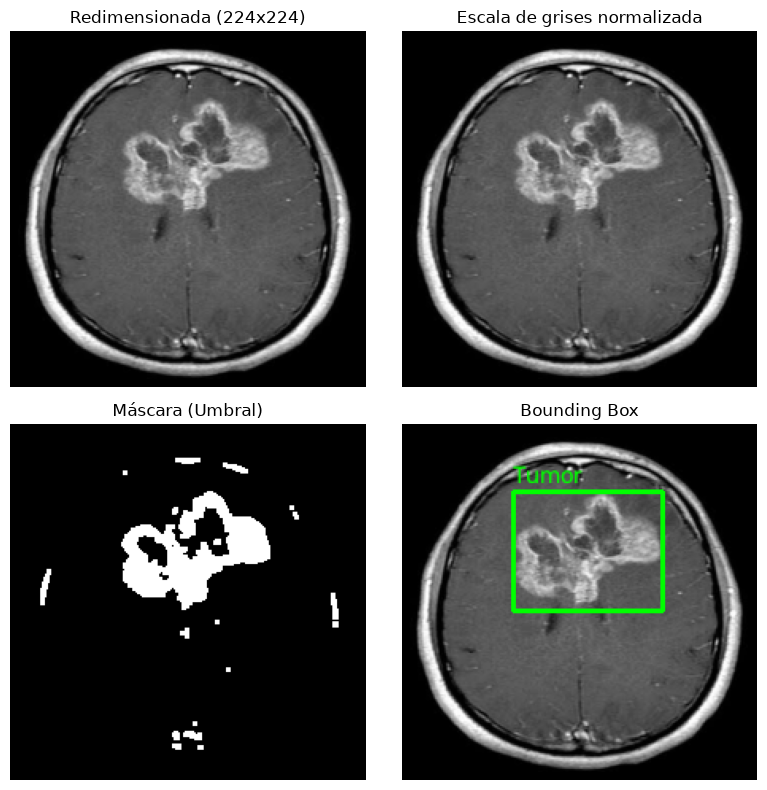

In [19]:

TAMANO_ESTANDAR = (224, 224)

def preprocesar_imagen(img_path, tamano=TAMANO_ESTANDAR):
    """
    Lee una imagen, la redimensiona a un tamaño estándar y normaliza
    sus intensidades al rango [0, 1].
    Retorna la imagen en color (BGR) y en escala de grises, ambas normalizadas.
    """
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, tamano, interpolation=cv2.INTER_AREA)

    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Normalización de intensidades al rango [0, 1]
    img_color_norm = img_resized.astype('float32') / 255.0
    img_gray_norm = img_gray.astype('float32') / 255.0

    return img_color_norm, img_gray_norm

# Prueba con una imagen de ejemplo
ejemplo_path = df_dataset_valido.iloc[0]['path']
color_norm, gray_norm = preprocesar_imagen(ejemplo_path)

print(f"Ruta de ejemplo: {ejemplo_path}")
print(f"Tamaño imagen color normalizada: {color_norm.shape}, rango: [{color_norm.min():.2f}, {color_norm.max():.2f}]")
print(f"Tamaño imagen gris normalizada:  {gray_norm.shape}, rango: [{gray_norm.min():.2f}, {gray_norm.max():.2f}]")

# --- Detección y dibujo del Bounding Box estrictamente interno ---
gray_uint8 = (gray_norm * 255).astype('uint8')

# 1. Aislar estrictamente el interior del cerebro y eliminar el cráneo por coordenadas/máscara
_, thresh_cabeza = cv2.threshold(gray_uint8, 20, 255, cv2.THRESH_BINARY)
contornos_cabeza, _ = cv2.findContours(thresh_cabeza, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contornos_cabeza:
    cnt_cabeza = max(contornos_cabeza, key=cv2.contourArea)
    mascara_cabeza = np.zeros_like(gray_uint8)
    cv2.drawContours(mascara_cabeza, [cnt_cabeza], -1, 255, -1)
    
    # Aplicar una erosión fuerte a la máscara de la cabeza para "cortar" el anillo óseo del cráneo
    kernel_craneo = np.ones((15, 15), np.uint8)
    mascara_cerebro_interno = cv2.erode(mascara_cabeza, kernel_craneo, iterations=1)
    
    cerebro_aislado = cv2.bitwise_and(gray_uint8, gray_uint8, mask=mascara_cerebro_interno)
else:
    cerebro_aislado = gray_uint8

# 2. Umbral dinámico para capturar la zona brillante del tumor en el centro
pixels_validos = cerebro_aislado[cerebro_aislado > 0]
if len(pixels_validos) > 0:
    valor_umbral = np.percentile(pixels_validos, 82) # Subimos un poco para evitar ruido sano
    _, mascara_tumor = cv2.threshold(cerebro_aislado, valor_umbral, 255, cv2.THRESH_BINARY)
else:
    mascara_tumor = cerebro_aislado

# 3. Limpieza de ruido menor
kernel_limpieza = np.ones((3, 3), np.uint8)
mascara_tumor = cv2.morphologyEx(mascara_tumor, cv2.MORPH_OPEN, kernel_limpieza)

# Asignamos para visualizar la máscara limpia en el panel 3
mascara_otsu = mascara_tumor 

# 4. Encontrar contornos solo en el área interna del cerebro
contornos, _ = cv2.findContours(mascara_tumor, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

imagen_visualizacion = (color_norm * 255).astype('uint8')

if contornos:
    # Tomar directamente el contorno más grande dentro de la zona cerebral interna
    cnt_tumor = max(contornos, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt_tumor)
    
    # Validar que tenga un tamaño coherente con una lesión
    if w > 15 and h > 15:
        cv2.rectangle(imagen_visualizacion, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(imagen_visualizacion, "Tumor", (x, y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    else:
        print("El contorno detectado es muy pequeño.")
else:
    print("No se encontró la región del tumor.")
    
# Visualización
plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor((color_norm * 255).astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title('Redimensionada (224x224)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gray_norm, cmap='gray')
plt.title('Escala de grises normalizada')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(mascara_otsu, cmap='gray')
plt.title('Máscara (Umbral)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(imagen_visualizacion, cv2.COLOR_BGR2RGB))
plt.title('Bounding Box')
plt.axis('off')

plt.tight_layout()
plt.show()

#### 4.1.4 Conversión de imágenes inválidas

Algunas imágenes válidas pueden llegar en formatos de canal distintos (escala de grises, RGBA, etc.). Se estandariza el número de canales a 3 (BGR) antes de continuar, de forma que todas las imágenes tengan el mismo formato para la extracción de características de color.


In [20]:
def convertir_formato_imagen(img):
    """
    Estandariza cualquier imagen a formato BGR de 3 canales.
    Convierte imágenes en escala de grises o con canal alfa (RGBA).
    """
    if img is None:
        return None
    if len(img.shape) == 2:
        # Escala de grises -> BGR
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        # RGBA -> BGR
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    return img

# Verificamos cuántos canales tiene cada imagen válida (muestra de 200)
canales_detectados = []
for path in df_dataset_valido['path'].sample(min(200, len(df_dataset_valido)), random_state=42):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    canales = 1 if img is None else (1 if len(img.shape) == 2 else img.shape[2])
    canales_detectados.append(canales)

canales_series = pd.Series(canales_detectados)
print("Distribución de número de canales detectados (muestra de 200 imágenes):")
print(canales_series.value_counts())


Distribución de número de canales detectados (muestra de 200 imágenes):
3    111
1     89
Name: count, dtype: int64


### 4.2 Extracción de características

Se define una función por cada grupo de características solicitado (color, estadísticas, textura y forma), y finalmente se combinan en una única función que procesa una imagen completa.


#### 4.2.1 Características de color

Se calcula la media de cada canal RGB, la media de cada canal HSV y el histograma de color (8 bins por canal) de la imagen redimensionada.


In [21]:
def extraer_caracteristicas_color(img_color_norm, bins=8):
    """
    Extrae media RGB, media HSV e histogramas de color de una imagen normalizada [0,1] en BGR.
    """
    img_uint8 = (img_color_norm * 255).astype('uint8')

    # Media RGB (convertimos de BGR a RGB para reportar en el orden habitual)
    img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2RGB)
    media_r, media_g, media_b = img_rgb[:, :, 0].mean(), img_rgb[:, :, 1].mean(), img_rgb[:, :, 2].mean()

    # Media HSV
    img_hsv = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2HSV)
    media_h, media_s, media_v = img_hsv[:, :, 0].mean(), img_hsv[:, :, 1].mean(), img_hsv[:, :, 2].mean()

    # Histogramas de color (uno por canal RGB, normalizados)
    hist_r = cv2.calcHist([img_rgb], [0], None, [bins], [0, 256]).flatten()
    hist_g = cv2.calcHist([img_rgb], [1], None, [bins], [0, 256]).flatten()
    hist_b = cv2.calcHist([img_rgb], [2], None, [bins], [0, 256]).flatten()
    hist_r = hist_r / (hist_r.sum() + 1e-7)
    hist_g = hist_g / (hist_g.sum() + 1e-7)
    hist_b = hist_b / (hist_b.sum() + 1e-7)

    return {
        'media_R': media_r, 'media_G': media_g, 'media_B': media_b,
        'media_H': media_h, 'media_S': media_s, 'media_V': media_v,
        'hist_R': hist_r, 'hist_G': hist_g, 'hist_B': hist_b
    }

# Prueba con la imagen de ejemplo
carac_color = extraer_caracteristicas_color(color_norm)
print("Medias RGB:", (carac_color['media_R'], carac_color['media_G'], carac_color['media_B']))
print("Medias HSV:", (carac_color['media_H'], carac_color['media_S'], carac_color['media_V']))
print("Histograma canal R (8 bins):", np.round(carac_color['hist_R'], 3))


Medias RGB: (np.float64(66.03192761479592), np.float64(66.03192761479592), np.float64(66.03192761479592))
Medias HSV: (np.float64(0.0), np.float64(0.0), np.float64(66.03192761479592))
Histograma canal R (8 bins): [0.368 0.037 0.389 0.077 0.049 0.042 0.022 0.016]


#### 4.2.2 Características estadísticas

A partir de la imagen en escala de grises se calculan medidas de tendencia central y dispersión (media, mediana, varianza, desviación estándar) y la entropía, que mide la cantidad de información/desorden en la distribución de intensidades.


In [22]:
def extraer_caracteristicas_estadisticas(img_gray_norm):
    """
    Extrae media, mediana, varianza, desviación estándar y entropía
    de una imagen en escala de grises normalizada [0,1].
    """
    img_uint8 = (img_gray_norm * 255).astype('uint8')

    media = np.mean(img_uint8)
    mediana = np.median(img_uint8)
    varianza = np.var(img_uint8)
    desv_std = np.std(img_uint8)

    # Entropía a partir del histograma de intensidades (probabilidades por nivel de gris)
    hist, _ = np.histogram(img_uint8, bins=256, range=(0, 256))
    prob = hist / (hist.sum() + 1e-7)
    entropia = scipy_entropy(prob, base=2)

    return {
        'media_gris': media, 'mediana_gris': mediana,
        'varianza_gris': varianza, 'desv_std_gris': desv_std,
        'entropia': entropia
    }

carac_stats = extraer_caracteristicas_estadisticas(gray_norm)
print("Características estadísticas de ejemplo:")
for k, v in carac_stats.items():
    print(f"  {k}: {v:.4f}")


Características estadísticas de ejemplo:
  media_gris: 66.0319
  mediana_gris: 80.0000
  varianza_gris: 3529.4301
  desv_std_gris: 59.4090
  entropia: 5.7399


#### 4.2.3 Características de textura

Se extraen dos descriptores de textura clásicos:
* **Local Binary Patterns (LBP)**: histograma uniforme (P=8, R=1) que resume 10 bins característicos de la textura local.
* **Histogram of Oriented Gradients (HOG)**: se reporta la media y desviación estándar del vector HOG como resumen, ya que el vector completo tiene una alta dimensionalidad.


In [23]:
def extraer_caracteristicas_textura(img_gray_norm):
    """
    Extrae el histograma de Local Binary Patterns (LBP) y un resumen del
    descriptor Histogram of Oriented Gradients (HOG) de una imagen en escala de grises.
    """
    img_uint8 = (img_gray_norm * 255).astype('uint8')

    # Local Binary Patterns
    radio = 1
    n_puntos = 8 * radio
    lbp = local_binary_pattern(img_uint8, n_puntos, radio, method='uniform')
    hist_lbp, _ = np.histogram(lbp, bins=np.arange(0, n_puntos + 3), range=(0, n_puntos + 2))
    hist_lbp = hist_lbp.astype('float')
    hist_lbp /= (hist_lbp.sum() + 1e-7)

    # Histogram of Oriented Gradients
    vector_hog = hog(img_gray_norm, orientations=9, pixels_per_cell=(16, 16),
                      cells_per_block=(2, 2), block_norm='L2-Hys', transform_sqrt=True)

    return {
        'lbp_hist': hist_lbp,
        'hog_mean': vector_hog.mean(),
        'hog_std': vector_hog.std(),
        'hog_dim': len(vector_hog)
    }

carac_textura = extraer_caracteristicas_textura(gray_norm)
print("Histograma LBP (10 bins):", np.round(carac_textura['lbp_hist'], 3))
print(f"HOG -> media: {carac_textura['hog_mean']:.4f}, std: {carac_textura['hog_std']:.4f}, dimensión: {carac_textura['hog_dim']}")


Histograma LBP (10 bins): [0.036 0.057 0.04  0.076 0.162 0.087 0.055 0.055 0.348 0.084]
HOG -> media: 0.1155, std: 0.1181, dimensión: 6084


#### 4.2.4 Características de forma

Se segmenta la región cerebral mediante el método de **Otsu** y, sobre la región de mayor área, se calculan:
* **Área**: número de píxeles de la región segmentada.
* **Perímetro**: longitud del contorno de la región.
* **Circularidad**: `4π·Área / Perímetro²` (se aproxima a 1 cuanto más circular es la forma).
* **Compacidad**: `Perímetro² / Área` (a menor valor, forma más compacta).


In [24]:
def extraer_caracteristicas_forma(img_gray_norm):
    """
    Segmenta la región principal de la imagen mediante Otsu y calcula
    área, perímetro, circularidad y compacidad de dicha región.
    """
    img_uint8 = (img_gray_norm * 255).astype('uint8')

    # Segmentación con el método de Otsu
    _, mask = cv2.threshold(img_uint8, 0, 1, cv2.THRESH_OTSU)

    etiquetas, num = label(mask, return_num=True)

    if num == 0:
        return {'area': 0, 'perimetro': 0, 'circularidad': 0, 'compacidad': 0}

    # Nos quedamos con la región de mayor área (la principal, ej. el cráneo/cerebro)
    props = regionprops(etiquetas)
    region_principal = max(props, key=lambda p: p.area)

    area = region_principal.area
    perimetro = region_principal.perimeter

    if perimetro == 0:
        circularidad, compacidad = 0, 0
    else:
        circularidad = (4 * np.pi * area) / (perimetro ** 2)
        compacidad = (perimetro ** 2) / area

    return {
        'area': area,
        'perimetro': perimetro,
        'circularidad': circularidad,
        'compacidad': compacidad
    }

carac_forma = extraer_caracteristicas_forma(gray_norm)
print("Características de forma de ejemplo:")
for k, v in carac_forma.items():
    print(f"  {k}: {v:.4f}")


Características de forma de ejemplo:
  area: 30418.0000
  perimetro: 2654.9699
  circularidad: 0.0542
  compacidad: 231.7334


#### 4.2.5 Extracción combinada y construcción del dataset de características

Se combinan las cuatro funciones anteriores en una sola rutina que procesa una imagen de principio a fin, y se aplica sobre una muestra balanceada del dataset (30 imágenes por categoría, siguiendo el mismo criterio de muestreo representativo utilizado en el Paso 3) para construir el DataFrame final `df_caracteristicas`.


In [25]:
def extraer_todas_caracteristicas(img_path):
    """
    Aplica el preprocesamiento y extrae todas las características
    (color, estadísticas, textura y forma) de una sola imagen.
    """
    color_norm, gray_norm = preprocesar_imagen(img_path)

    color = extraer_caracteristicas_color(color_norm)
    stats_ = extraer_caracteristicas_estadisticas(gray_norm)
    textura = extraer_caracteristicas_textura(gray_norm)
    forma = extraer_caracteristicas_forma(gray_norm)

    fila = {
        'media_R': color['media_R'], 'media_G': color['media_G'], 'media_B': color['media_B'],
        'media_H': color['media_H'], 'media_S': color['media_S'], 'media_V': color['media_V'],
        **{f'hist_R_{i}': v for i, v in enumerate(color['hist_R'])},
        **{f'hist_G_{i}': v for i, v in enumerate(color['hist_G'])},
        **{f'hist_B_{i}': v for i, v in enumerate(color['hist_B'])},
        'media_gris': stats_['media_gris'], 'mediana_gris': stats_['mediana_gris'],
        'varianza_gris': stats_['varianza_gris'], 'desv_std_gris': stats_['desv_std_gris'],
        'entropia': stats_['entropia'],
        **{f'lbp_{i}': v for i, v in enumerate(textura['lbp_hist'])},
        'hog_mean': textura['hog_mean'], 'hog_std': textura['hog_std'],
        'area': forma['area'], 'perimetro': forma['perimetro'],
        'circularidad': forma['circularidad'], 'compacidad': forma['compacidad']
    }
    return fila

# Muestra balanceada: 30 imágenes por categoría (ajustar N_MUESTRA según capacidad de cómputo)
N_MUESTRA = 30
partes = []
for categoria_actual, grupo in df_dataset_valido.groupby('categoria'):
    partes.append(grupo.sample(min(N_MUESTRA, len(grupo)), random_state=42))
df_muestra_caract = pd.concat(partes).reset_index(drop=True)

registros_caract = []
for idx, row in df_muestra_caract.iterrows():
    fila = extraer_todas_caracteristicas(row['path'])
    fila['categoria'] = row['categoria']
    fila['set'] = row['set']
    registros_caract.append(fila)

df_caracteristicas = pd.DataFrame(registros_caract)

print("=" * 60)
print("DATASET DE CARACTERÍSTICAS CONSTRUIDO")
print("=" * 60)
print(f"Imágenes procesadas: {len(df_caracteristicas)}")
print(f"Número de características por imagen: {df_caracteristicas.shape[1] - 2}")
df_caracteristicas.head()


DATASET DE CARACTERÍSTICAS CONSTRUIDO
Imágenes procesadas: 120
Número de características por imagen: 51


,media_R,media_G,media_B,media_H,media_S,media_V,hist_R_0,hist_R_1,hist_R_2,hist_R_3,...,lbp_8,lbp_9,hog_mean,hog_std,area,perimetro,circularidad,compacidad,categoria,set
0,34.857422,34.857422,34.857422,0.0,0.0,34.857422,0.580935,0.151208,0.174546,0.043228,...,0.454759,0.065589,0.112600,0.122878,19304.0,2487.033801,0.039219,320.417381,glioma,Training
1,38.995715,38.995715,38.995715,0.0,0.0,38.995715,0.431740,0.369878,0.148976,0.031031,...,0.197066,0.113122,0.130866,0.103207,26374.0,4089.822869,0.019814,634.209870,glioma,Training
2,43.573701,43.573701,43.573701,0.0,0.0,43.573701,0.423051,0.316267,0.170440,0.054030,...,0.207011,0.103037,0.127359,0.107505,25627.0,3985.793432,0.020271,619.914515,glioma,Training
3,45.772182,45.772182,45.772182,0.0,0.0,45.772182,0.388772,0.286790,0.231645,0.057079,...,0.226224,0.100626,0.123026,0.112438,26099.0,3997.531455,0.020523,612.293871,glioma,Training
4,21.331852,21.331852,21.331852,0.0,0.0,21.331852,0.612863,0.335021,0.035973,0.012376,...,0.518296,0.072664,0.106749,0.126703,20547.0,2091.636831,0.059018,212.923767,glioma,Testing


#### 4.2.6 Resumen de características por categoría

Se muestra un resumen estadístico de las características de forma y de textura agrupadas por categoría, útil para verificar que el proceso de extracción se realizó correctamente antes de pasar al modelado.


In [26]:
print("=" * 80)
print("RESUMEN DE CARACTERÍSTICAS DE FORMA POR CATEGORÍA")
print("=" * 80)
display(df_caracteristicas.groupby('categoria')[['area', 'perimetro', 'circularidad', 'compacidad']].mean().round(3))

print("\n" + "=" * 80)
print("RESUMEN DE CARACTERÍSTICAS ESTADÍSTICAS Y DE TEXTURA POR CATEGORÍA")
print("=" * 80)
display(df_caracteristicas.groupby('categoria')[['media_gris', 'desv_std_gris', 'entropia', 'hog_mean']].mean().round(3))


RESUMEN DE CARACTERÍSTICAS DE FORMA POR CATEGORÍA


,area,perimetro,circularidad,compacidad
categoria,,,,
glioma,20295.833,2574.372,0.043,344.663
meningioma,18499.033,2664.213,0.078,409.308
notumor,18536.633,3331.715,0.037,823.268
pituitary,25018.933,4063.703,0.024,691.268



RESUMEN DE CARACTERÍSTICAS ESTADÍSTICAS Y DE TEXTURA POR CATEGORÍA


,media_gris,desv_std_gris,entropia,hog_mean
categoria,,,,
glioma,35.112,38.654,5.422,0.117
meningioma,46.339,46.442,5.815,0.120
notumor,58.203,60.181,5.825,0.120
pituitary,49.935,40.385,6.428,0.133


## Paso 5: Construcción del Dataset

En esta fase, procedemos a formalizar el dataset estructurado generado en la etapa anterior. El objetivo es persistir los datos en un formato estándar (.csv) que facilite la portabilidad y el entrenamiento de modelos, además de realizar una validación exhaustiva de la calidad, integridad y estructura de las variables extraídas. Finalmente, preparamos los datos mediante una partición estratificada para asegurar una evaluación representativa en las etapas de modelado. 

### Persistencia del Dataset

Guardamos el DataFrame resultante de la extracción de características como un archivo CSV.

In [27]:
# Definir la ruta de salida
directorio_trabajo = "./data_proyecto"
nombre_archivo = "dataset_tumores_estructurado.csv"
ruta_csv = os.path.join(directorio_trabajo, nombre_archivo)

# Guardar el dataset
# index=False evita guardar la columna extra de números de fila (0, 1, 2...)
df_caracteristicas.to_csv(ruta_csv, index=False, encoding='utf-8')

print(f"Dataset estructurado guardado exitosamente en: {ruta_csv}")

Dataset estructurado guardado exitosamente en: ./data_proyecto\dataset_tumores_estructurado.csv


### Verificación de Calidad del Dataset

Una vez construido el dataset estructurado, se realiza una validación para comprobar que la información generada sea consistente antes de utilizarla en modelos de Machine Learning.

**Revisión de valores faltantes.**

Se verifica que ninguna de las características extraídas presente valores nulos (NaN), garantizando que todas las imágenes procesadas generaron correctamente sus características.

In [28]:
# Revisión de valores faltantes (NaN)
faltantes = df_caracteristicas.isnull().sum()

if faltantes.sum() > 0:
    print("¡Advertencia! Se han detectado valores faltantes:")
    print(faltantes[faltantes > 0])
else:
    print("Dataset libre de valores faltantes.")

Dataset libre de valores faltantes.


**Revisión de consistencia de etiquetas**

Se muestran las categorías presentes en el dataset para verificar que únicamente existan las cuatro clases diagnósticas originales.

In [29]:
# Verificación de las clases presentes en el dataset
print("\nClases detectadas en el dataset:")
print(df_caracteristicas['categoria'].unique())


Clases detectadas en el dataset:
<StringArray>
['glioma', 'meningioma', 'notumor', 'pituitary']
Length: 4, dtype: str


**Revisión de la estructura del dataset**

Se verifica el tamaño del conjunto de datos y el número total de características extraídas por imagen.

In [30]:
# Mostrar dimensiones generales del dataset
print("\nDimensiones del Dataset:")
print(df_caracteristicas.shape)

# Restamos las columnas 'categoria' y 'set',
# ya que corresponden a información de identificación
print(f"Número de características: {df_caracteristicas.shape[1]-2}")


Dimensiones del Dataset:
(120, 53)
Número de características: 51


**Verificación de los tipos de datos**

Se comprueba que cada variable tenga el tipo de dato esperado (numérico para las características y texto para las etiquetas).

In [31]:
# Mostrar el tipo de dato de cada columna
print("\nTipos de datos del dataset:")
print(df_caracteristicas.dtypes)


Tipos de datos del dataset:
media_R          float64
media_G          float64
media_B          float64
media_H          float64
media_S          float64
media_V          float64
hist_R_0         float32
hist_R_1         float32
hist_R_2         float32
hist_R_3         float32
hist_R_4         float32
hist_R_5         float32
hist_R_6         float32
hist_R_7         float32
hist_G_0         float32
hist_G_1         float32
hist_G_2         float32
hist_G_3         float32
hist_G_4         float32
hist_G_5         float32
hist_G_6         float32
hist_G_7         float32
hist_B_0         float32
hist_B_1         float32
hist_B_2         float32
hist_B_3         float32
hist_B_4         float32
hist_B_5         float32
hist_B_6         float32
hist_B_7         float32
media_gris       float64
mediana_gris     float64
varianza_gris    float64
desv_std_gris    float64
entropia         float64
lbp_0            float64
lbp_1            float64
lbp_2            float64
lbp_3            floa

**Detección de registros duplicados**

Finalmente, se verifica que no existan filas duplicadas dentro del dataset estructurado.

In [32]:
# Comprobar si existen registros duplicados
duplicados = df_caracteristicas.duplicated().sum()

print(f"\nNúmero de filas duplicadas: {duplicados}")


Número de filas duplicadas: 1


In [33]:
# COMPROBAR: Contar cuántas filas totalmente duplicadas existen
filas_duplicadas = df_caracteristicas.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame: {filas_duplicadas}")

# (Opcional) Si quieres ver cuáles son esas filas duplicadas en pantalla:
display(df_caracteristicas[df_caracteristicas.duplicated(keep=False)])

Número de filas duplicadas en el DataFrame: 1


,media_R,media_G,media_B,media_H,media_S,media_V,hist_R_0,hist_R_1,hist_R_2,hist_R_3,...,lbp_8,lbp_9,hog_mean,hog_std,area,perimetro,circularidad,compacidad,categoria,set
72,52.820193,52.820193,52.820193,0.0,0.0,52.820193,0.381417,0.143276,0.370137,0.046895,...,0.161312,0.06525,0.133035,0.100397,22527.0,1828.972834,0.084625,148.494768,notumor,Training
89,52.820193,52.820193,52.820193,0.0,0.0,52.820193,0.381417,0.143276,0.370137,0.046895,...,0.161312,0.06525,0.133035,0.100397,22527.0,1828.972834,0.084625,148.494768,notumor,Training


In [34]:
# BORRAR: Eliminar los duplicados conservando solo la primera ocurrencia
df_caracteristicas = df_caracteristicas.drop_duplicates().reset_index(drop=True)

# ACTUALIZAR: Sobrescribir el archivo CSV con el dataset limpio
df_caracteristicas.to_csv(ruta_csv, index=False, encoding='utf-8')

# VERIFICACIÓN FINAL: Confirmar que ya no quedan duplicados y ver las nuevas dimensiones
print(f"\n¡Duplicados eliminados exitosamente!")
print(f"Nuevas dimensiones del dataset: {df_caracteristicas.shape}")
print(f"Filas duplicadas actuales: {df_caracteristicas.duplicated().sum()}")


¡Duplicados eliminados exitosamente!
Nuevas dimensiones del dataset: (119, 53)
Filas duplicadas actuales: 0


**Vista previa del dataset generado**

Como verificación final, se muestran las primeras filas del dataset estructurado para comprobar que todas las características fueron almacenadas correctamente.

In [35]:
# Mostrar una vista previa del dataset final
print("\nPrimeras 5 filas del dataset:")
display(df_caracteristicas.head())


Primeras 5 filas del dataset:


,media_R,media_G,media_B,media_H,media_S,media_V,hist_R_0,hist_R_1,hist_R_2,hist_R_3,...,lbp_8,lbp_9,hog_mean,hog_std,area,perimetro,circularidad,compacidad,categoria,set
0,34.857422,34.857422,34.857422,0.0,0.0,34.857422,0.580935,0.151208,0.174546,0.043228,...,0.454759,0.065589,0.112600,0.122878,19304.0,2487.033801,0.039219,320.417381,glioma,Training
1,38.995715,38.995715,38.995715,0.0,0.0,38.995715,0.431740,0.369878,0.148976,0.031031,...,0.197066,0.113122,0.130866,0.103207,26374.0,4089.822869,0.019814,634.209870,glioma,Training
2,43.573701,43.573701,43.573701,0.0,0.0,43.573701,0.423051,0.316267,0.170440,0.054030,...,0.207011,0.103037,0.127359,0.107505,25627.0,3985.793432,0.020271,619.914515,glioma,Training
3,45.772182,45.772182,45.772182,0.0,0.0,45.772182,0.388772,0.286790,0.231645,0.057079,...,0.226224,0.100626,0.123026,0.112438,26099.0,3997.531455,0.020523,612.293871,glioma,Training
4,21.331852,21.331852,21.331852,0.0,0.0,21.331852,0.612863,0.335021,0.035973,0.012376,...,0.518296,0.072664,0.106749,0.126703,20547.0,2091.636831,0.059018,212.923767,glioma,Testing
